In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import io
import base64
from jupyter_bbox_widget import BBoxWidget
import matplotlib.patches as patches


In [2]:
def show_mask(mask, ax, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), [0.6]])
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])

    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)

    ax.imshow(mask_image)

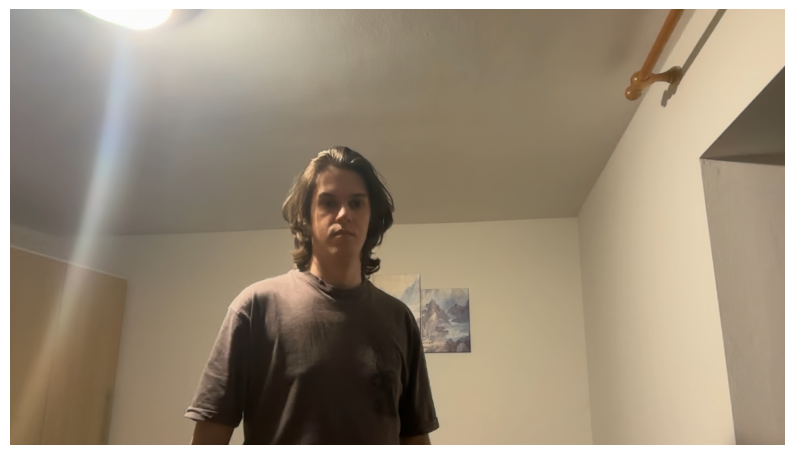

In [85]:
import time

# Open a connection to the webcam
cap = cv2.VideoCapture(0)

# Check if the webcam is opened correctly
if not cap.isOpened():
    raise IOError("Cannot open webcam")

# Read a frame from the webcam
time.sleep(5)  # Wait for the webcam to initialize
ret, frame = cap.read()

# Close the connection to the webcam
cap.release()

# Convert the image from BGR to RGB
image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis("off")
plt.show()


In [86]:
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

image_tensor = F.to_tensor(image)

with torch.no_grad():
    prediction = model([image_tensor])

person_label = 1
threshold = 0.5

labels = prediction[0]["labels"]
all_boxes = prediction[0]["boxes"]
all_scores = prediction[0]["scores"]

mask = (labels == person_label) & (all_scores > threshold)

boxes = all_boxes[mask]
scores = all_scores[mask]

print("Boxes:", boxes)
print("Scores:", scores)

Boxes: tensor([[ 426.2559,  344.2043, 1055.4614, 1077.8961]])
Scores: tensor([0.9993])


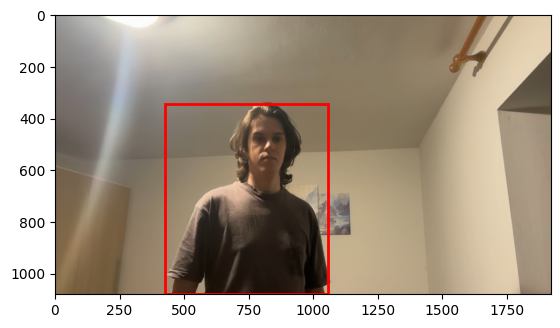

In [87]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a matplotlib figure
fig, ax = plt.subplots(1)

# Display the image
ax.imshow(image)

for box in boxes:
    x1, y1, x2, y2 = box.detach().numpy()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)

    

# Show the figure
plt.show()

In [88]:
from segment_anything import sam_model_registry, SamPredictor

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "data/sam_vit_h_4b8939.pth"
model_type = "vit_h"

device="cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)




In [89]:
print(boxes)

tensor([[ 426.2559,  344.2043, 1055.4614, 1077.8961]])


In [91]:
import cv2
import numpy as np

predictor.set_image(image)


masks, scores, logits = predictor.predict(
    box=boxes[0].cpu().numpy(),
    multimask_output=True
)

[0.9358646 1.0114175 1.0074093]


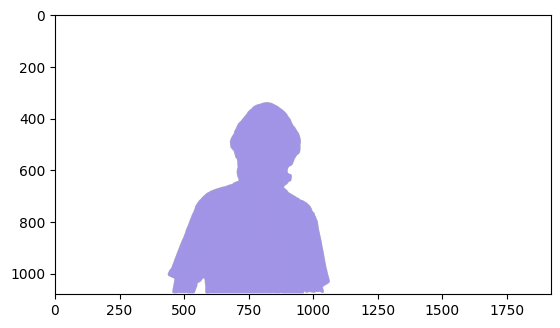

In [92]:
print(scores)

#take the index of the highest score


max_score = np.argmax(scores) 

# Select the mask with the highest score
mask_with_max_score = masks[max_score]

show_mask(mask_with_max_score, plt.gca())


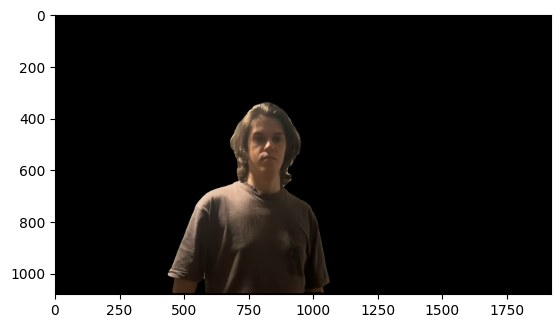

In [93]:


mask_with_max_score = mask_with_max_score.astype(bool)


masked_image = image.copy()
masked_image[~mask_with_max_score] = 0

# Display the masked image
plt.imshow(masked_image)
plt.show()

In [94]:
background_image = cv2.imread('data/road.jpg')
background_image = cv2.cvtColor(background_image, cv2.COLOR_BGR2RGB)


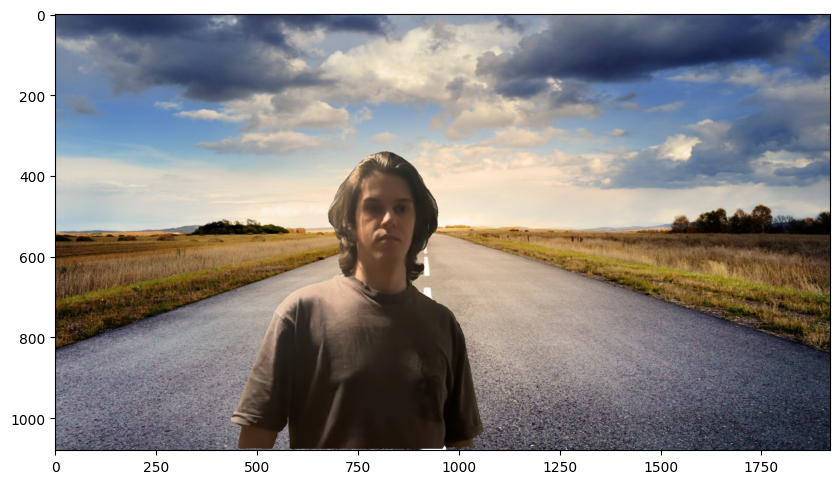

In [95]:
# Make sure the background image is the same size as the original image
background_image = cv2.resize(background_image, (image.shape[1], image.shape[0]))


composite_image = np.where(
    mask_with_max_score[..., None],
    image,
    background_image
)

plt.figure(figsize=(10,10))

# Display the composite image
plt.imshow(composite_image)
plt.show()